# DETECT FAKE IMAGE USING RESNET-50


This project uses a pre-trained ResNet-50 deep learning model for image classification. The main goal is to transform the model's final classification layer from 1000 layers (ImageNet) into two binary layers: Real and Fake.

Prequisites:
- Install all packages in requirement.txt by running following commands:
```python
python3 -m venv venv
source venv/bin/activate
pip install -r requirements.txt
```
- Download dataset from Kaggle (zip file) and save at: `/datasets/dataset.zip:`https://www.kaggle.com/datasets/shreyanshpatel1/130k-real-vs-fake-face 

# 1. Extract dataset and display data information
The code below will automatically extract the `dataset.zip` file (if not already extracted) and count the number of real/fake images in the data.
We can find the extracted dataset at: `/datasets/extracted_data/images/`
There are two subfolders:
- `/fake`: contains FLUX_DEV, FLUX_PRO and SDXL model generated images
- `/real`: contains real images

In [1]:
import os
import zipfile
from pathlib import Path

# config path
DATASET_ZIP = "../datasets/dataset.zip"
EXTRACT_DIR = "../datasets/extracted_data"

# 1. Extract dataset
if not os.path.exists(EXTRACT_DIR):
    print(f"Extracting {DATASET_ZIP} in {EXTRACT_DIR}...")
    with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extract dataset successfully!")
else:
    print(f"The dataset is extracted in {EXTRACT_DIR}.")

# 2. Show dataset info (number of images by folders)
print("\n--- Dataset information ---")
extracted_path = Path(EXTRACT_DIR)
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}
total_images = 0

# Loop into subfolders in folder "images"
for real_fake_dir in sorted(extracted_path.glob("images/*")):
    if real_fake_dir.is_dir():
        print(f"\nCategory: {real_fake_dir.name}")
        for category_dir in sorted(real_fake_dir.iterdir()):
            if category_dir.is_dir():
                images_count = sum(
                    1 for file in category_dir.iterdir() 
                    if file.suffix.lower() in image_extensions
                )
                print(f"  - {category_dir.name}: {images_count} images")
                total_images += images_count

print(f"\nTotal images in dataset: {total_images} images")

The dataset is extracted in ../datasets/extracted_data.

--- Dataset information ---

Category: fake
  - FLUX_DEV: 7273 images
  - FLUX_PRO: 3209 images
  - SDXL: 53087 images

Category: real

Category: test

Total images in dataset: 63569 images


# 2. Prepare Data (Train/Val Split) for Real/Fake Images
- We will combine all real images (label = 0) and fake images (label = 1) into a single dataset. 
- Then we split this dataset into 80% for Training (Train), 10% for Validation (Val), and 10% for final Testing (Test) for the ResNet model.

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

EXTRACT_DIR = "../datasets/extracted_data"
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}
RANDOM_STATE = 42

dataset_info = []

# 1. Collect Real images (Label 0)
real_dir = Path(EXTRACT_DIR) / "images" / "real"
for img_path in real_dir.rglob("*"):
    if img_path.suffix.lower() in image_extensions:
        dataset_info.append({"path": str(img_path.resolve()), "label": 0, "classname": "real"})

# 2. Collect Fake images (Label 1)
fake_dir = Path(EXTRACT_DIR) / "images" / "fake"
for img_path in fake_dir.rglob("*"):
    if img_path.suffix.lower() in image_extensions:
        dataset_info.append({"path": str(img_path.resolve()), "label": 1, "classname": "fake"})

# 3. Convert to DataFrame for easy statistics and splitting
df = pd.DataFrame(dataset_info)
print(f"Total collected images: {len(df)}")
print("\nLabel distribution:")
print(df['classname'].value_counts())

# 4. Train / Val / Test Split (80% - 10% - 10%)
# Step 1: Split 80% Train, 20% remaining (Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['label'])
# Step 2: Split the remaining 20% in half (into 10% Val and 10% Test)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_STATE, stratify=temp_df['label'])

print(f"\nTraining set images: {len(train_df)}")
print(f"Validation set images: {len(val_df)}")
print(f"Test set images: {len(test_df)}")

# Save DataFrame to CSV files as reference for subsequent functions
# TODO: Change the location of CSV
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)
print("\nSuccessfully saved split dataset catalog to CSV files.")

Total collected images: 133569

Label distribution:
classname
real    70000
fake    63569
Name: count, dtype: int64

Training set images: 106855
Validation set images: 13357
Test set images: 13357

Successfully saved split dataset catalog to CSV files.


### The following code will show 5 samples each class (real, fake).

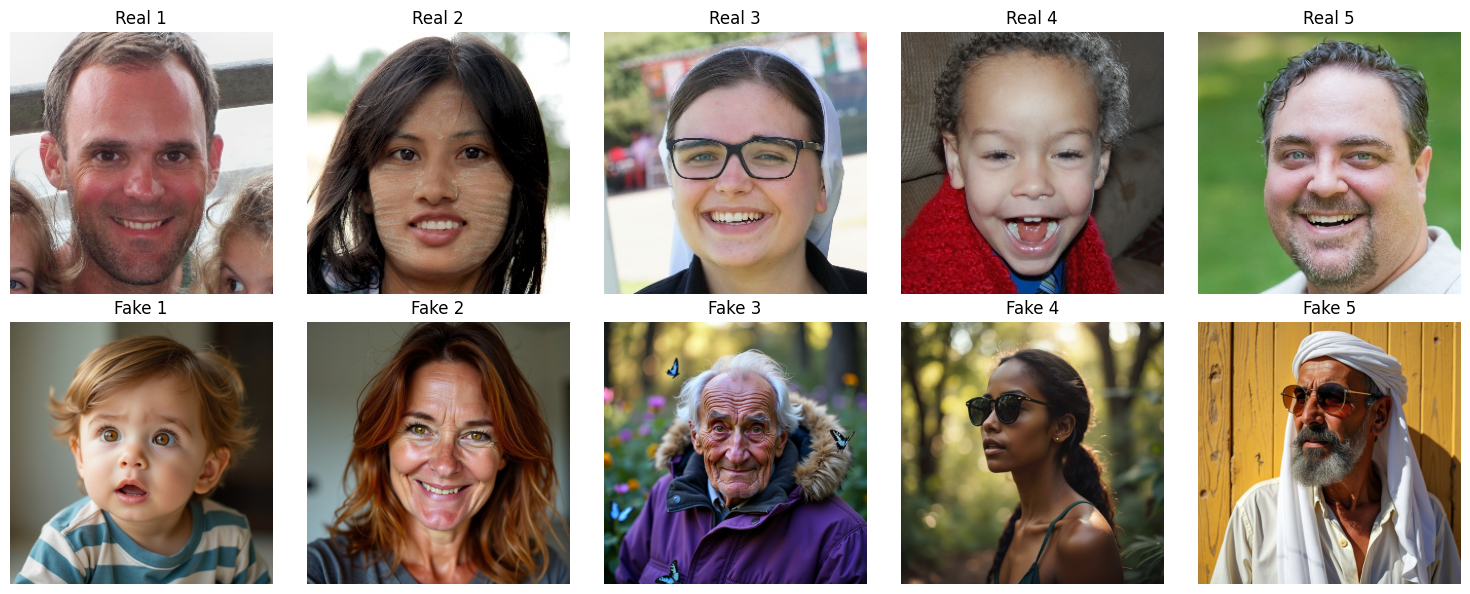

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

# Get 5 real and 5 fake images from the DataFrame
real_images = df[df['label'] == 0]['path'].head(5).tolist()
fake_images = df[df['label'] == 1]['path'].head(5).tolist()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Display 5 Real images on row 1
for i, img_path in enumerate(real_images):
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Real {i+1}")
    axes[0, i].axis('off')

# Display 5 Fake images on row 2
for i, img_path in enumerate(fake_images):
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Fake {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 3. PyTorch Dataset & DataLoader Configuration
Build a Custom PyTorch Dataset that loads path and label information from `train_split.csv` and `val_split.csv`. 
This process also uses `torchvision.transforms` to perform Data Augmentation (Flipping, color adjustments, etc.) which helps the model encounter various forms of AI image artifacts and avoid overfitting.

In [5]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd

DEFAULT_SIZE = (224, 224)
DEFAULT_MEAN = [0.485, 0.456, 0.406]
DEFAULT_STD = [0.229, 0.224, 0.225]
BATCH_SIZE = 32

# Define Augmentations to avoid overfitting
# Note: resizing to 224x224 - this is the standard architecture for ImageNet models.
train_transforms = transforms.Compose([
    transforms.Resize(DEFAULT_SIZE),
    transforms.RandomHorizontalFlip(p=0.5), # Horizontal flip 50% of the time
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), # Slight color jitter
    transforms.ToTensor(),
    transforms.Normalize(mean= DEFAULT_MEAN, std=DEFAULT_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize(DEFAULT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=DEFAULT_MEAN, std=DEFAULT_STD)
])

# Custom PyTorch Dataset Class
class RealFakeDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['path']
        label = self.data.iloc[idx]['label']
        
        # Load image using PIL - convert RGBA to RGB for ResNet compatibility
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            # Handle cases with corrupted/broken files in the dataset
            print(f"Error loading image: {img_path} - {e}")
            image = Image.new('RGB', DEFAULT_SIZE, (255, 255, 255))
            
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# Initialize Datasets
train_dataset = RealFakeDataset(csv_file="train_split.csv", transform=train_transforms)
val_dataset = RealFakeDataset(csv_file="val_split.csv", transform=val_transforms)
test_dataset = RealFakeDataset(csv_file="test_split.csv", transform=val_transforms)

# Initialize DataLoader - Group images into Batches, e.g. 32 images at a time

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Data loading complete! Train Loader: {len(train_loader)} batches | Val Loader: {len(val_loader)} batches | Test Loader: {len(test_loader)} batches.")

Data loading complete! Train Loader: 3340 batches | Val Loader: 418 batches | Test Loader: 418 batches.


# 4. Model Setup & Configuration
Use the powerful `ResNet50` network architecture. Instead of having it guess 1000 animals (default ImageNet), we replace its final interpretation layer (Fully Connected layer) with a branch containing exactly 2 outputs: Real or Fake. This process is called "Transfer Learning".

In [6]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# 1. Determine device explicitly (MPS for Apple Silicon Mac)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Starting initialization on device: {device}")

# 2. Load pretrained ResNet50 model from PyTorch ImageNet
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# 5X SPEEDUP SOLUTION: FREEZE BACKBONE
# Instead of updating gradients for all 25 million parameters, we freeze them all!
# This saves a lot of VRAM and Training time on Mac.
for param in model.parameters():
    param.requires_grad = False

# 3. Replace the final layer: default ResNet50 has in_features=2048, predicting 1000 values (ImageNet).
# Reattach the final layer: in_features=2048 outputs exactly 2 results (Real, Fake)
# PyTorch automatically sets requires_grad = True for this new layer.
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) 

# Move the model to GPU/MPS
model = model.to(device)

print("ResNet50 model setup and parameter freezing completed!")

Starting initialization on device: mps
ResNet50 model setup and parameter freezing completed!


# 5. Build Training and Validation Loop (Training & Validation Phases)
This is a mandatory process in the Machine Learning Workflow:

**Step 1: Training Phase:** 
Input the Train set (80% of images). The algorithm will calculate the error (Loss) and automatically update the network to fit the data (reduce Error).

**Step 2: Validation Phase & Fine-tuning:** 
After completing each Epoch, we immediately input the Validation set (10%) to test. 
Important: The model will completely Not learn (No_Grad) from this dataset, it just "guesses". This result helps us evaluate the intelligence and fine-tune hyperparameters. Repeat these 2 steps until satisfied and save the best version!

In [ ]:
import time
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # Progress bar library

# Configure Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()

# Optimizer ONLY fine-tunes 1 single layer which is `model.fc`
optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-2)

# Loop: Set num_epochs = 10 as requested
num_epochs = 10 
best_val_acc = 0.0

print(f"\n🚀 Starting training - {num_epochs} Epochs!")

# Initialize lists to store history for drawing charts
history_train_loss = []
history_train_acc = []
history_val_loss = []
history_val_acc = []

for epoch in range(num_epochs):
    start_time = time.time()
    
    # ===============================
    # STEP 1: TRAINING PHASE
    # ===============================
    model.train() # Turn on Weight Update mode again
    running_train_loss = 0.0
    correct_train = 0

    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

    for images, labels in train_progress:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()      # Reset gradients
        outputs = model(images)    # Calculate prediction (Forward)
        loss = criterion(outputs, labels) # Calculate error
        
        loss.backward()            # Backward pass
        optimizer.step()           # Adjust Model 
        
        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels)
        
        train_progress.set_postfix({'loss': f"{loss.item():.4f}"})
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc = correct_train.float() / len(train_dataset) * 100

    # ===============================
    # STEP 2: VALIDATION PHASE
    # ===============================
    model.eval() # Turn off Weight Update feature (VRAM significantly drops)
    running_val_loss = 0.0
    correct_val = 0

    val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)

    with torch.no_grad(): # Prevent gradients during validation
        for images, labels in val_progress:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels)
            
            val_progress.set_postfix({'loss': f"{loss.item():.4f}"})
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_val.float() / len(val_dataset) * 100
    
    elapsed_time = time.time() - start_time

    # QUICK REPORT OF THIS LOOP'S RESULTS
    print(f"| Epoch [{epoch+1}/{num_epochs}] - "
          f"Time: {elapsed_time:.0f}s - "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% |")

    # Save to history for chart drawing
    history_train_loss.append(epoch_train_loss)
    history_train_acc.append(epoch_train_acc.cpu().item())
    history_val_loss.append(epoch_val_loss)
    history_val_acc.append(epoch_val_acc.cpu().item())

    # SAVE BEST STATE BASED ON VAL SET
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "resnet50_best_real_fake.pth")

print(f"\nTrain & Val process completed! Best milestone recorded: {best_val_acc:.2f}%\n")

# ===============================
# STEP 3: PLOT ACCURACY & LOSS CHARTS
# ===============================
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss Chart
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_train_loss, label='Train Loss', marker='o', color='blue')
plt.plot(epochs_range, history_val_loss, label='Val Loss', marker='o', color='red')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Accuracy Chart
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_train_acc, label='Train Accuracy', marker='o', color='blue')
plt.plot(epochs_range, history_val_acc, label='Val Accuracy', marker='o', color='red')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/Users/khang/Downloads/lab02/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 6. Final Test (Testing Phase & Confusion Matrix)
**Step 3: Final Test (Testing Phase):** 
Now, we will Reload the best weights saved in Step 2.

Input the remaining **Test** set (Which the Model has never seen until now, nor was it used to adjust Val settings) and run the prediction exactly once. If the result is good and produces a clean Confusion Matrix, it means the AI did not overfit or show bias!

Re-evaluating accuracy on the entire final TEST set...


Testing:   0%|          | 0/418 [00:00<?, ?it/s]/Users/khang/Downloads/lab02/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



--- Classification Report On TEST Set ---
                     precision    recall  f1-score   support

               REAL       1.00      1.00      1.00      7000
FAKE (AI Generated)       1.00      1.00      1.00      6357

           accuracy                           1.00     13357
          macro avg       1.00      1.00      1.00     13357
       weighted avg       1.00      1.00      1.00     13357



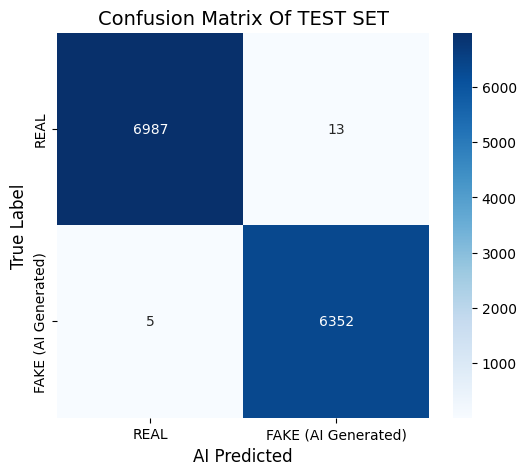

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# STEP 3: TESTING (RELOAD WEIGHTS AND RUN INDEPENDENT TEST SET)
model.load_state_dict(torch.load("resnet50_best_real_fake.pth", weights_only=True))

model.eval()

y_true = []
y_pred = []

print("Re-evaluating accuracy on the entire final TEST set...")
with torch.no_grad():
    # RUN TEST_LOADER (NOT val_loader)
    test_progress = tqdm(test_loader, desc="Testing", leave=False)
    for images, labels in test_progress:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        # Convert tensor to 1D numpy array so it can be passed into sklearn library
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# CLASSIFICATION REPORT: View Precision, Recall for each Label
target_names = ["REAL", "FAKE (AI Generated)"]
print("\n--- Classification Report On TEST Set ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# DRAW CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('AI Predicted', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix Of TEST SET', fontsize=14)
plt.show()

# 7. Application Testing (Inference)
- We build a function to automatically load any image from the folder path and pass it to the neural network we just trained to determine its probability of being a Fake image. 
- We can easily change the path to a file downloaded from the Internet to use it directly.

Tìm thấy 10 ảnh. Đang tiến hành dự đoán...



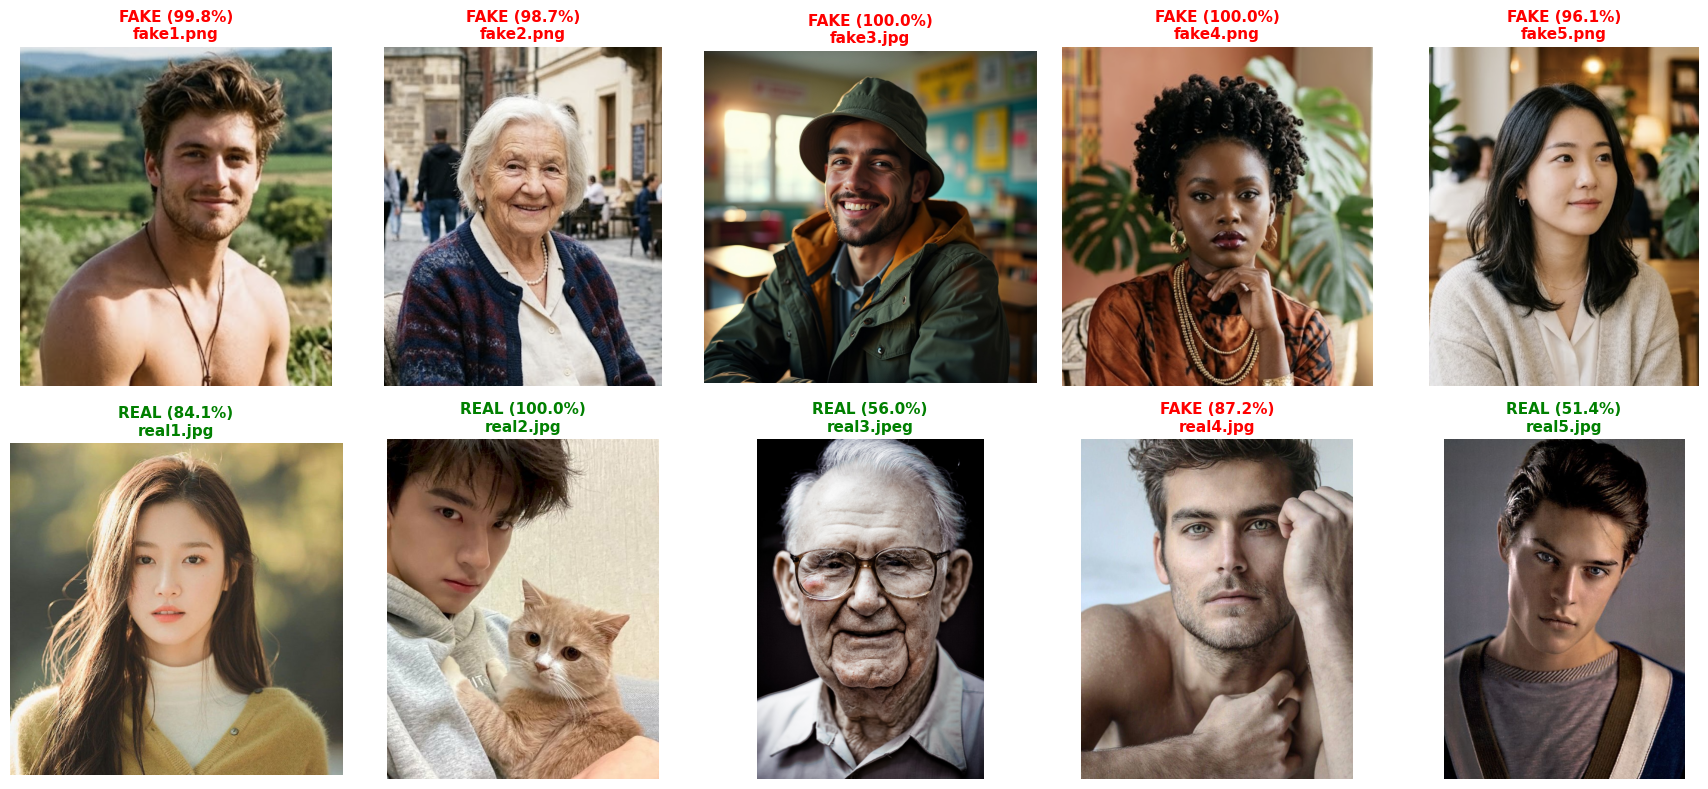

In [ ]:
import os
import math
import torch
import torch.nn as nn
from torchvision.models import resnet50
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Determine device explicitly and load model components
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

# Load model structure and load weights from file (no need to train again)
model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("resnet50_best_real_fake.pth", map_location=device, weights_only=True))
model = model.to(device)
model.eval()

# Preprocessing configuration
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_images_in_folder(folder_path, max_cols=5):
    """
    Take a directory as input, scan all images and show grid type predictions.
    Max {max_cols} images per row.
    """
    folder_dir = Path(folder_path)
    if not folder_dir.exists() or not folder_dir.is_dir():
        print(f"Directory {folder_path} does not exist or is invalid!")
        return
        
    image_extensions = {".jpg", ".jpeg", ".png", ".webp"}
    # Sort images alphabetically
    image_paths = sorted([p for p in folder_dir.iterdir() if p.suffix.lower() in image_extensions])
    
    num_images = len(image_paths)
    if num_images == 0:
        print(f"No valid image (jpg/png/webp) found in {folder_path}!")
        return
        
    print(f"Found {num_images} images. Proceeding to predict...\n")
    
    # Calculate number of rows/cols to display on Matplotlib
    cols = min(max_cols, num_images)
    rows = math.ceil(num_images / cols)
    
    fig = plt.figure(figsize=(cols * 3.5, rows * 4))
    
    for i, img_path in enumerate(image_paths):
        try:
            img = Image.open(img_path).convert("RGB")
            
            # Format to Tensor Matrix (1, 3, 224, 224) so model can process it
            img_tensor = preprocess(img).unsqueeze(0).to(device) 
            
            with torch.no_grad():
                outputs = model(img_tensor)
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                confidence, predicted_class = torch.max(probabilities, 1)
                
            is_fake = predicted_class.item() == 1
            label = "FAKE" if is_fake else "REAL"
            score = confidence.item() * 100
            color = "red" if is_fake else "green"
            
            # Init drawing area for each image (subplot)
            ax = fig.add_subplot(rows, cols, i + 1)
            ax.imshow(img)
            ax.axis('off')
            
            # Substring file name if it gets too long (more than 15 characters, add ...)
            short_name = img_path.name if len(img_path.name) <= 15 else img_path.name[:12] + "..."
            ax.set_title(f"{label} ({score:.1f}%)\n{short_name}", color=color, fontsize=11, fontweight='bold')
            
        except Exception as e:
            print(f"Error processing image {img_path.name}: {e}")
            
    plt.tight_layout()
    plt.show()

# ==================================
# EXECUTE:
# Provide any image folder path you desire
test_folder_path = "../datasets/extracted_data/images/test"

if os.path.exists(test_folder_path):
    predict_images_in_folder(test_folder_path, max_cols=5)
else:
    print("Please update a valid folder path at the test_folder_path variable!")